# Categorization of Cyber Security Attacks on IOT Infrastructure #
##### by Andi (B.A.) Rodríguez Macuacé

In [1]:
#Importing project libraries
import os, time 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC



## Descriptive Analysis of Data

The Dataset used for this project was obtained from Kaggle's "Cyber Attacks on Real-Time Internet of Things", It is a proprietary dataset collected from a
real IoT network infrastructure and includes both normal and malicious traffic flows representing real world scenarios.

link: https://www.kaggle.com/datasets/joebeachcapital/real-time-internet-of-things-rt-iot2022/data

In [2]:
# Importing dataset
attacks_data = pd.read_csv("../dataset/RT_IOT2022.csv", sep=",")

# Show data info
print("--- Basic Information ---")
print(attacks_data.info())
print("\n--- Basic Statistics ---")
print(attacks_data.describe())

row_count = len(attacks_data)
print("\n--- Total number of samples: ", row_count, "---")
print("--- Number of Attack data samples per Attack_type  ---")
original_counts = attacks_data.groupby('Attack_type').size()
print(original_counts)

--- Basic Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123117 entries, 0 to 123116
Data columns (total 85 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0                123117 non-null  int64  
 1   id.orig_p                 123117 non-null  int64  
 2   id.resp_p                 123117 non-null  int64  
 3   proto                     123117 non-null  object 
 4   service                   123117 non-null  object 
 5   flow_duration             123117 non-null  float64
 6   fwd_pkts_tot              123117 non-null  int64  
 7   bwd_pkts_tot              123117 non-null  int64  
 8   fwd_data_pkts_tot         123117 non-null  int64  
 9   bwd_data_pkts_tot         123117 non-null  int64  
 10  fwd_pkts_per_sec          123117 non-null  float64
 11  bwd_pkts_per_sec          123117 non-null  float64
 12  flow_pkts_per_sec         123117 non-null  float64
 13  down_up_ratio     

In [3]:
#Checking for missing values
print("\n--- Missing Values ---")
print(attacks_data.isnull().sum())


--- Missing Values ---
Unnamed: 0              0
id.orig_p               0
id.resp_p               0
proto                   0
service                 0
                       ..
idle.std                0
fwd_init_window_size    0
bwd_init_window_size    0
fwd_last_window_size    0
Attack_type             0
Length: 85, dtype: int64


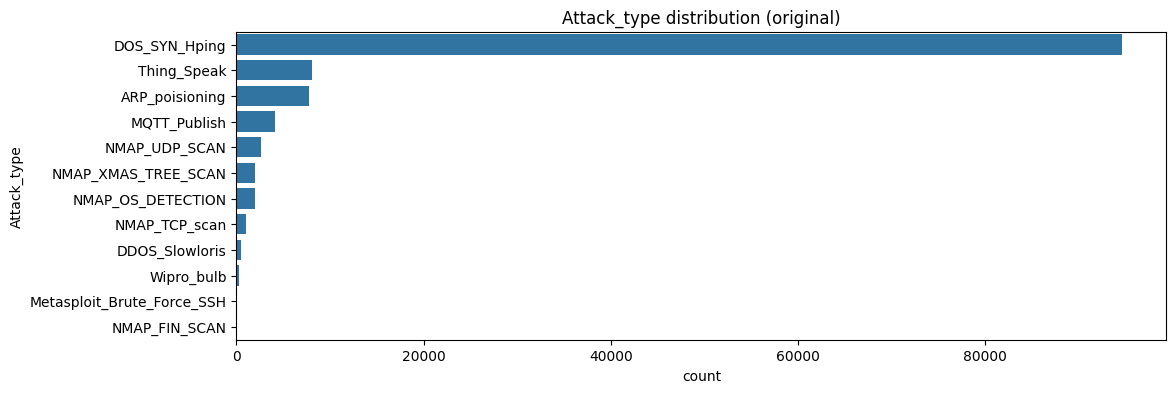

In [4]:
#Visualizing Initial Class distribution
plt.figure(figsize=(12,4))
sns.countplot(y='Attack_type', data=attacks_data, order=attacks_data['Attack_type'].value_counts().index)
plt.title("Attack_type distribution (original)")
plt.show()



--- Plotting Initial Feature Distributions ---


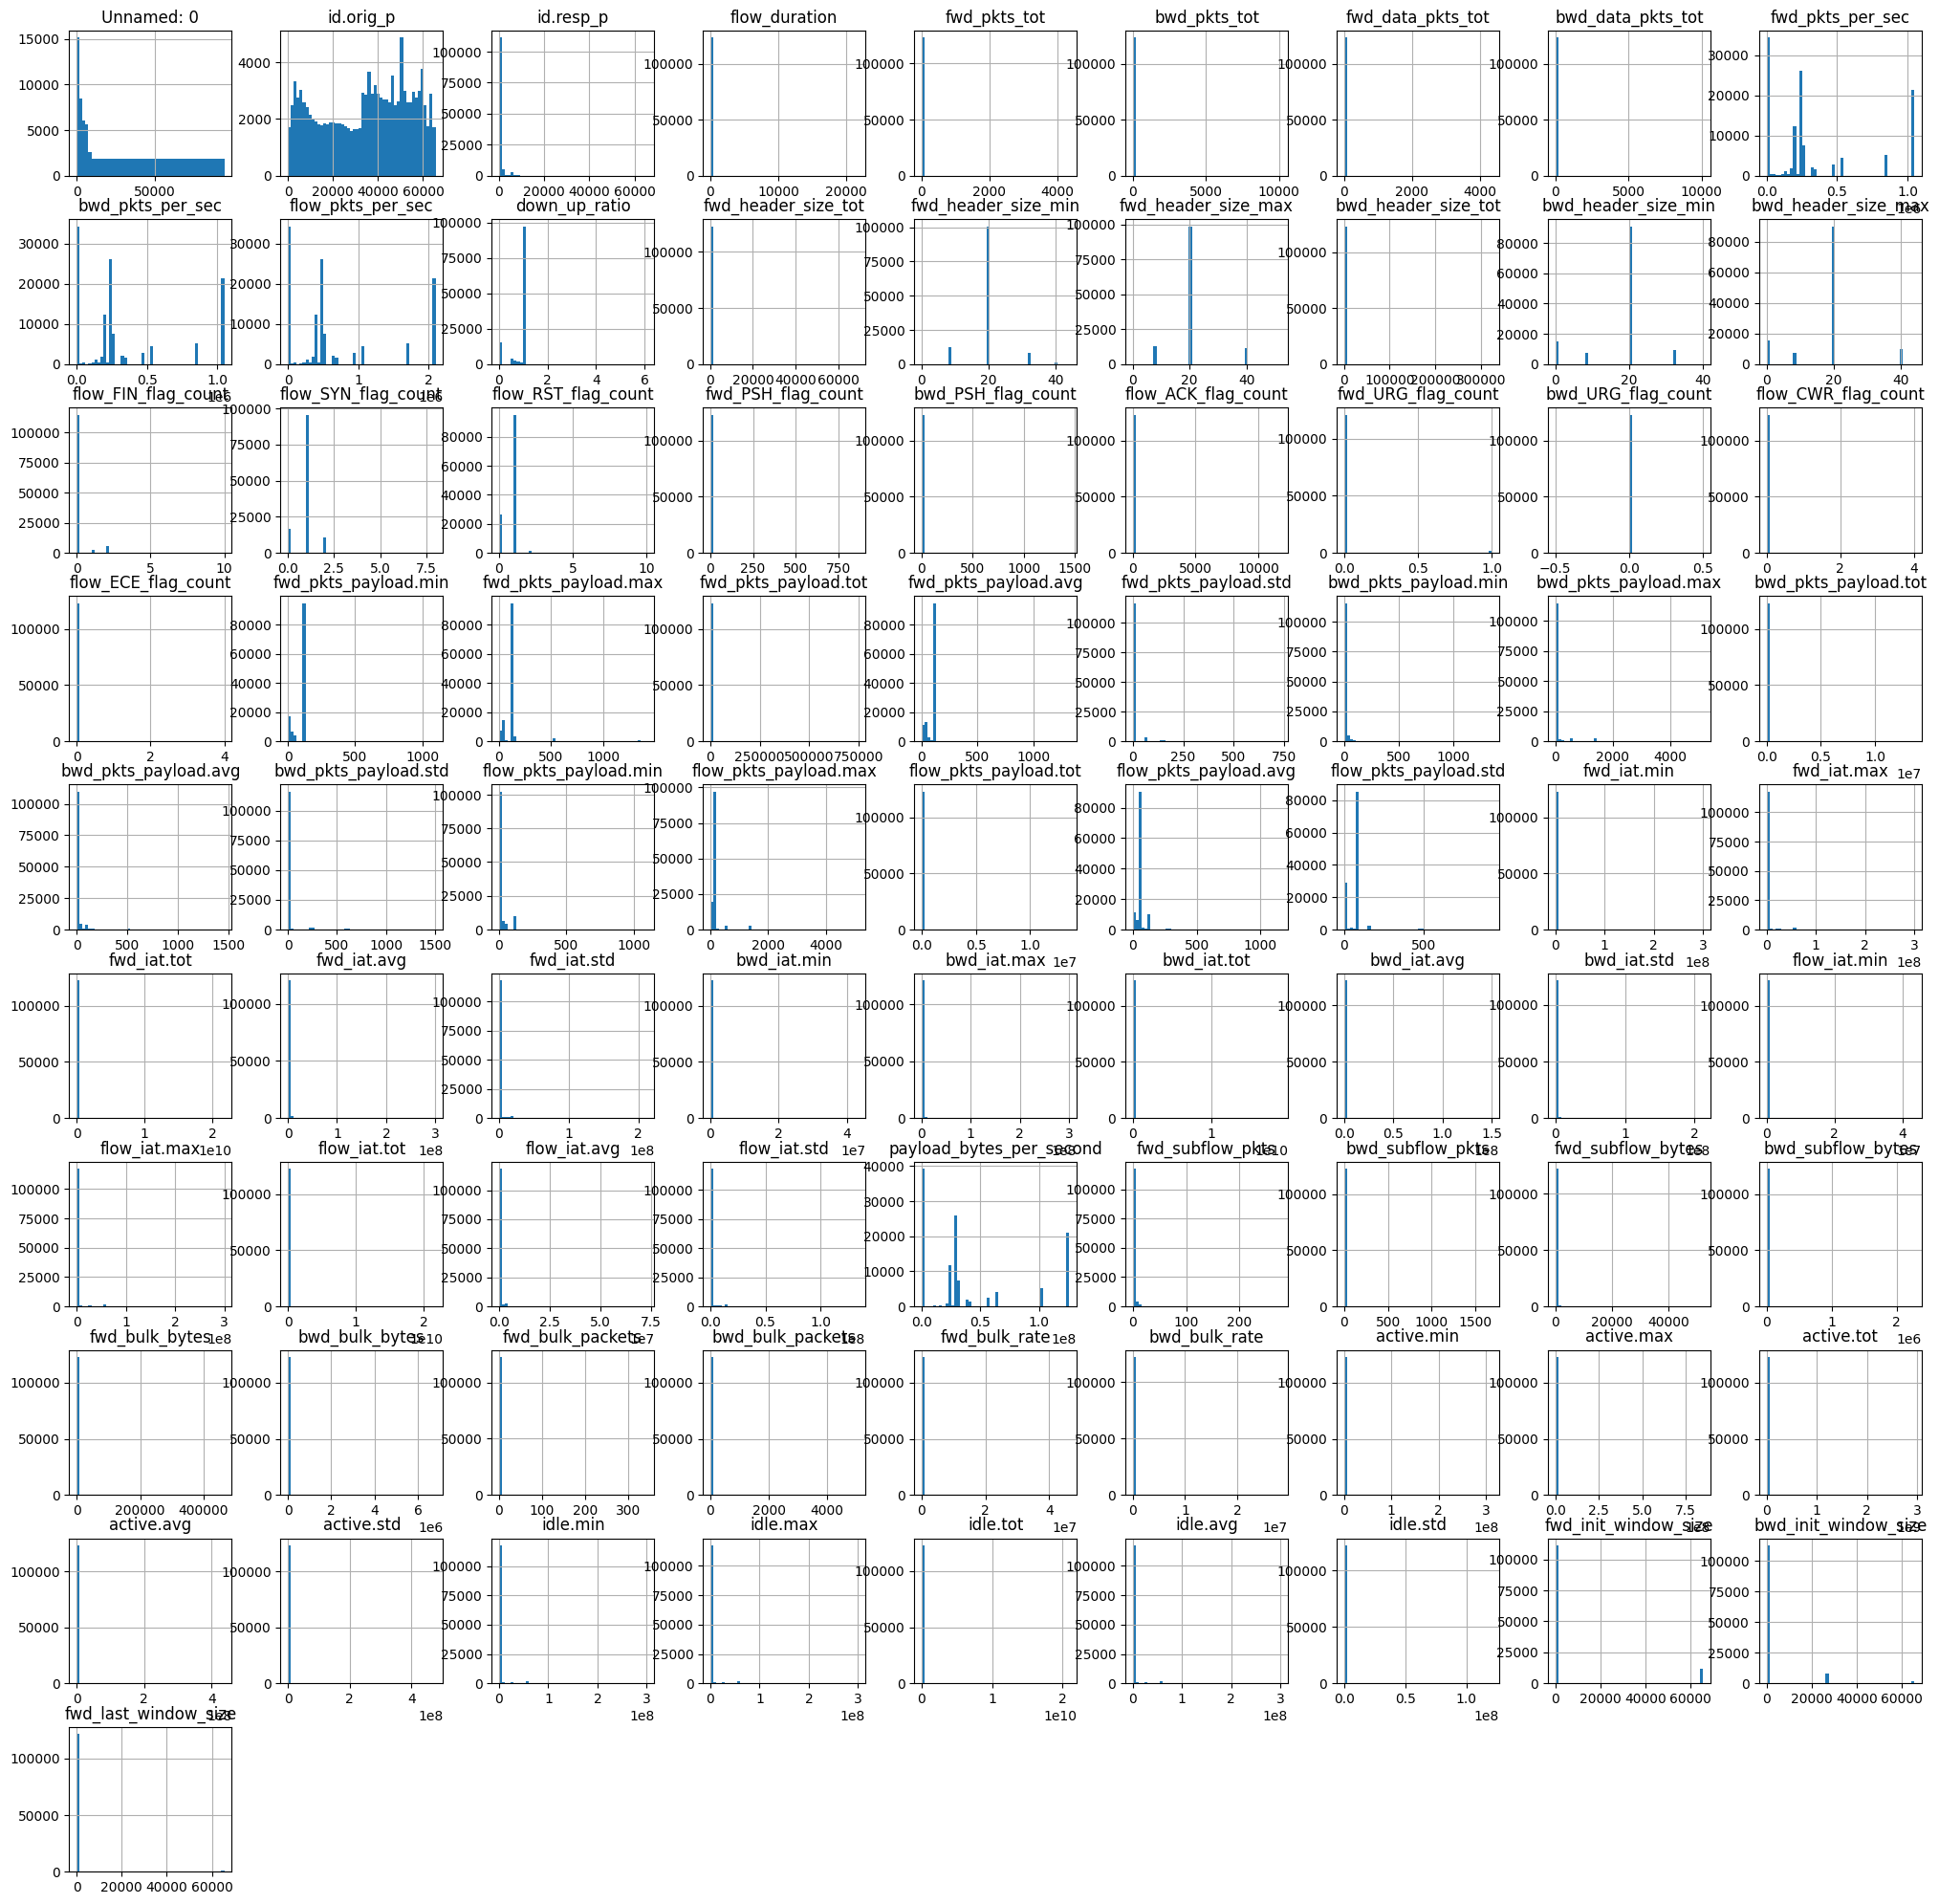

In [5]:
numeric_cols = attacks_data.select_dtypes(include=['int64', 'float64']).columns

#Visualizing Feature distribution histograms
print("\n--- Plotting Initial Feature Distributions ---")
attacks_data[numeric_cols].hist(bins=50, figsize=(25, 25))
plt.title("Raw Feature Distributions")
plt.show()


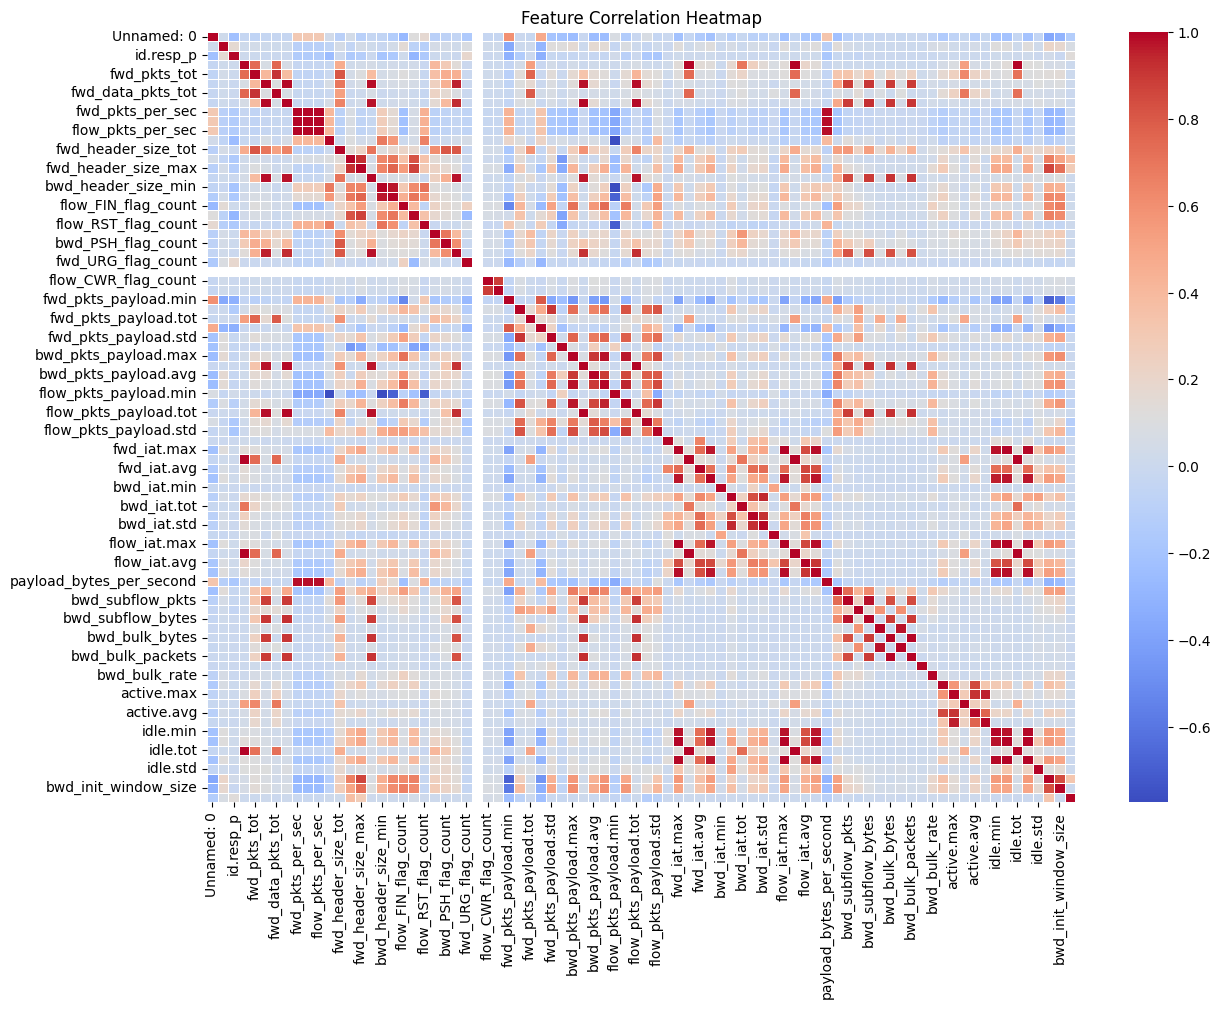

In [6]:
#Visualizing Feature Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(attacks_data[numeric_cols].corr(), cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# Initial Visualization Results
The target distribution plot shows a very big imbalance in the dataset, where the attack type DOS-SYN flood has a total of 94.659 samples, which will most likely affect the accuracy of the model's prediction. This attack type should be removed from the dataset.

The feature distribution plot shows that most features are very right-skewed and heavily-tailed, with a big spike near zero and a long tail for bigger values, making the dataset not normally distributed. Scaling should be implemented when applying models like logistic regression.

The correlation heatmap of the features revealed several strongly correlated groups like the different packet payload statistics, inter-arrival-time statistics, and bulk transfer metrics. Keeping all of these redundant variables can introduce multicollinearity for linear models and unnecessarily increase dimensionality.


## Implementation of necessary pre-processing

In [7]:
#Remove SYN flood attacks from dataset
filtered_attacks_data = attacks_data.loc[attacks_data['Attack_type'] != 'DOS_SYN_Hping']
filtered_row_count = len(filtered_attacks_data)
print("\n--- Attacks data samples without DOS_SYN_Hping: ",filtered_row_count, " ---")
filtered_counts = filtered_attacks_data.groupby('Attack_type').size()
print(filtered_counts)

#Remove ID column as it is not needed for analysis
filtered_attacks_data = filtered_attacks_data.drop(columns=['id.orig_p', 'id.resp_p'])



--- Attacks data samples without DOS_SYN_Hping:  28458  ---
Attack_type
ARP_poisioning                7750
DDOS_Slowloris                 534
MQTT_Publish                  4146
Metasploit_Brute_Force_SSH      37
NMAP_FIN_SCAN                   28
NMAP_OS_DETECTION             2000
NMAP_TCP_scan                 1002
NMAP_UDP_SCAN                 2590
NMAP_XMAS_TREE_SCAN           2010
Thing_Speak                   8108
Wipro_bulb                     253
dtype: int64


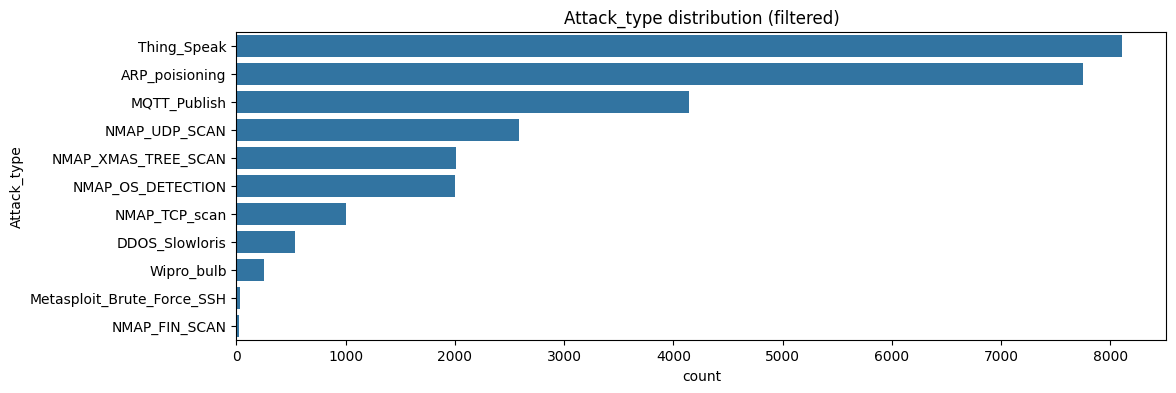

In [8]:
# Visualization of New target Distribution (Attack type)
plt.figure(figsize=(12,4))
sns.countplot(y='Attack_type', data=filtered_attacks_data, order=filtered_attacks_data['Attack_type'].value_counts().index)
plt.title("Attack_type distribution (filtered)")
plt.show()

In [9]:
#Separating Features and Target
X = filtered_attacks_data.drop('Attack_type', axis=1)
y = filtered_attacks_data['Attack_type']

#correlation prunning of features
corr = X.select_dtypes(include=[np.number]).corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

#drop features with any correlation > 0.95
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print("Dropping", len(to_drop), "highly correlated features")
X_reduced = X.drop(columns=to_drop)

# Show reduced data features
print("---Reduced Features---")
print(X_reduced.info())

Dropping 26 highly correlated features
---Reduced Features---
<class 'pandas.core.frame.DataFrame'>
Index: 28458 entries, 0 to 123116
Data columns (total 56 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                28458 non-null  int64  
 1   proto                     28458 non-null  object 
 2   service                   28458 non-null  object 
 3   flow_duration             28458 non-null  float64
 4   fwd_pkts_tot              28458 non-null  int64  
 5   bwd_pkts_tot              28458 non-null  int64  
 6   fwd_data_pkts_tot         28458 non-null  int64  
 7   fwd_pkts_per_sec          28458 non-null  float64
 8   down_up_ratio             28458 non-null  float64
 9   fwd_header_size_tot       28458 non-null  int64  
 10  fwd_header_size_min       28458 non-null  int64  
 11  fwd_header_size_max       28458 non-null  int64  
 12  bwd_header_size_min       28458 non-null  int64  
 13  flo

In [10]:
# function for encoding all text-based features and target
def labelEncodingFunction(X, y):
    label_encoders = {}
    for column in X.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        X[column] = le.fit_transform(X[column])
        label_encoders[column] = le
    le_target = LabelEncoder()
    y_encoded = le_target.fit_transform(y)
    return X, y_encoded, label_encoders

X, y_encoded, label_encoders = labelEncodingFunction(X_reduced, y)


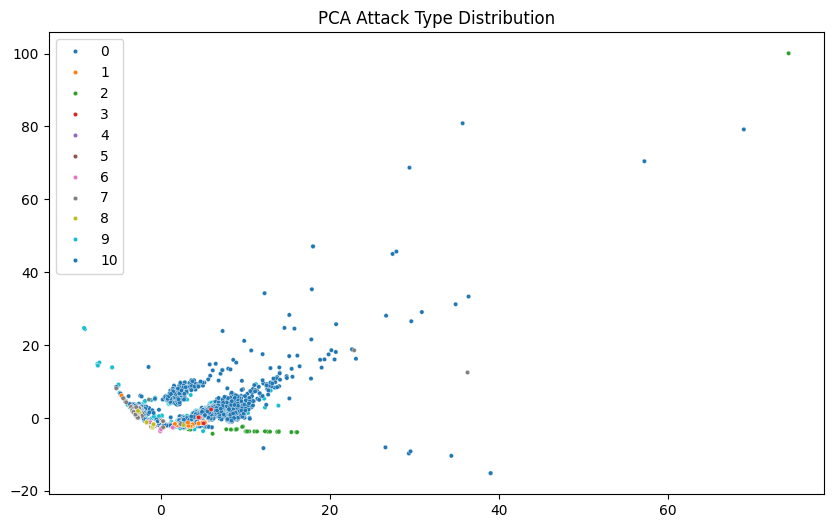

In [11]:
# perform a PCA in the dataset to see distribution of the different types.
# Scale full dataset for PCA
scaler_pca = StandardScaler()
X_scaled_for_pca = scaler_pca.fit_transform(X)

pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(X_scaled_for_pca)

plt.figure(figsize=(10,6))
sns.scatterplot(
    x=X_pca_2d[:,0],
    y=X_pca_2d[:,1],
    hue=y_encoded,
    palette="tab10",
    s=10
)
plt.title("PCA Attack Type Distribution")
plt.show()

### PCA justification and analysis

During the review session the teacher suggested the application of PCA to the dataset to have a better understanding of how attacks spread and whether separation was possible.

This visualization shows that a small number of classes are spread over a big region dominating feature space, while minority clases tend to overlap between different groups. This can cause issues in classification with linear models.

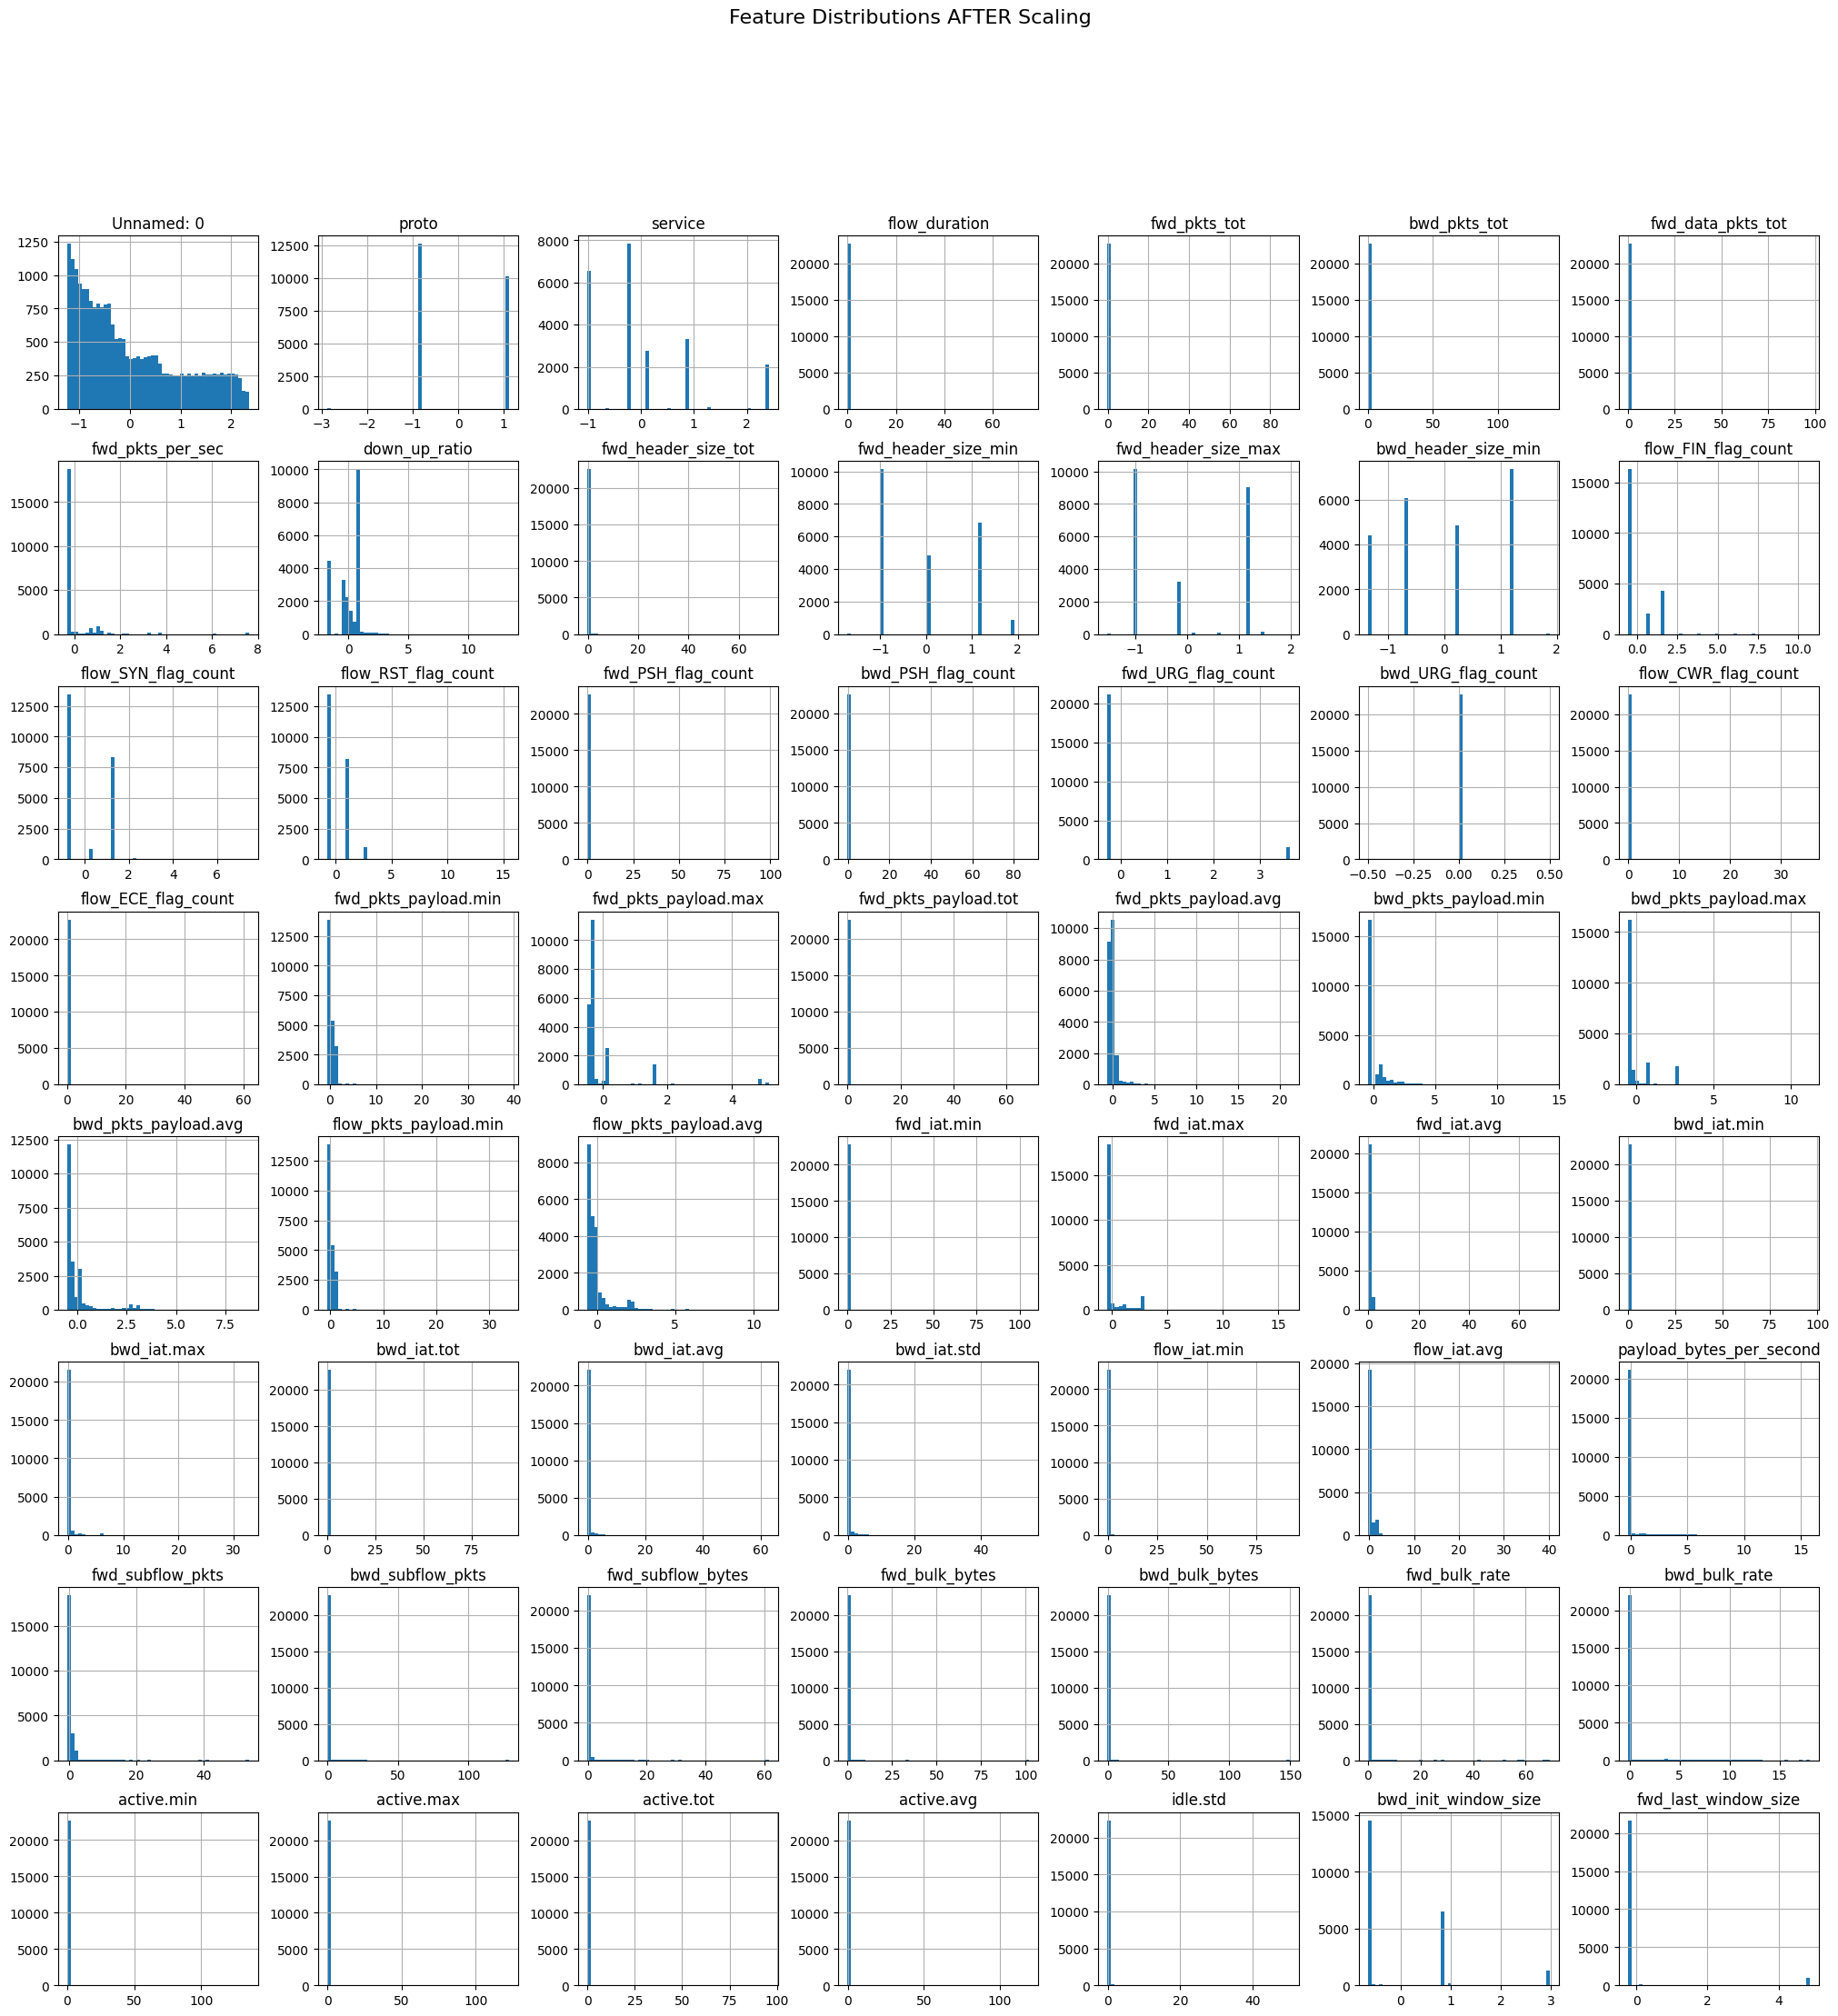

In [15]:
#Split dataset into test and train sets for X and y with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)

#Scale the data for feature range normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Visualizing feature distributions after scaling
scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

scaled_df.hist(figsize=(25,25), bins=50)
plt.suptitle("Feature Distributions AFTER Scaling", fontsize=16)
plt.show()

In [16]:
#Using SMote to balance the dataset
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

#class distribution before and after SMOTE
print("Class distribution before SMOTE:", Counter(y_train))
print("Class distribution after SMOTE:", Counter(y_train_balanced))

Class distribution before SMOTE: Counter({np.int64(9): 6486, np.int64(0): 6200, np.int64(2): 3317, np.int64(7): 2072, np.int64(8): 1608, np.int64(5): 1600, np.int64(6): 802, np.int64(1): 427, np.int64(10): 202, np.int64(3): 30, np.int64(4): 22})
Class distribution after SMOTE: Counter({np.int64(6): 6486, np.int64(9): 6486, np.int64(0): 6486, np.int64(7): 6486, np.int64(5): 6486, np.int64(2): 6486, np.int64(1): 6486, np.int64(8): 6486, np.int64(3): 6486, np.int64(10): 6486, np.int64(4): 6486})


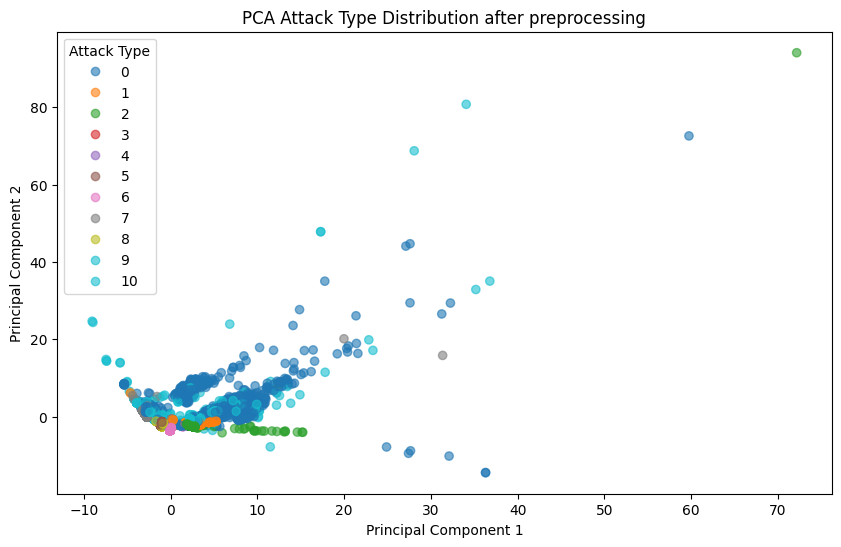

In [17]:
# performing a PCA in the balanced/scaled dataset to see distribution of the different types after preprocessing
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(10,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train, cmap='tab10', alpha=0.6)
plt.title("PCA Attack Type Distribution after preprocessing")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(*scatter.legend_elements(), title="Attack Type")
plt.show()

### Pre-processing justifications

For the initial cleaning of the data the category DOS_SYN_Hping was removed from the dataset as it had a big dominance over the other classes and created too big of an imbalance. Additionally , as it is custom in the pre-processing of data for machine learning models, identifier columns such as id.orig_p and id.resp_p were removed to prevent overfitting and to avoid these features influencing the model.

The correlation heat map showed that multiple features contained the same network metadata, so in order to avoid (or reduce) multicollinearity in the base model, features with a correlation higher than 0.95 were removed, leaving a total of 56 features.

Label encoding was performed to on the three text-based features (proto, service and Attack_type) so they can be turn to numbers, and hence be processed by the model.

When doing the data exploration with histograpms it was found that features needed to be scaled to remove magnitude differencees and avoid dominance of large features, this enhances the performance of models like logistic regression and SVM. For this features where scaled using StandardScaler.

In order to handle the severe class imbalance present in the dataset, overfitting with SMOTE was applied in order to prevent bias in classification models.

Finally, after pre-processing steps dimensionality reduction with PCA was applied and plotted to inspect feature distribution and compare with the initial one. This confirmed that pre-processing helped, as classes now form tighther clusters and there's a clearer separation for some categories.

## Selection of baseline model
Because the problem at hand focuses on (multiclass) classification tasks, the baseline model will be Logistic Regression as it is fast, easy to interpret and overall has a good reputation of performance for this type of cases.

In [18]:
#Initializing Logistic Regression Model as baseline model
baseline_model = LogisticRegression(max_iter=1000, random_state=42)

#training baseline model
baseline_model.fit(X_train_balanced, y_train_balanced)

#Making prediction
y_prediction = baseline_model.predict(X_test_scaled)
y_probability = baseline_model.predict_proba(X_test_scaled)

#Displaying baseline model performance
print("Classification Report: \n", classification_report(y_test, y_prediction))

print("\nAccuracy: ", accuracy_score(y_test, y_prediction))
print("\nF1-score: ", f1_score(y_test, y_prediction, average='weighted'))
print("\nROC-AUC: ", roc_auc_score(y_test, y_probability, multi_class='ovr'))
print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_prediction))


Classification Report: 
               precision    recall  f1-score   support

           0       0.95      0.90      0.93      1550
           1       0.80      0.95      0.87       107
           2       1.00      1.00      1.00       829
           3       0.20      0.86      0.32         7
           4       0.42      0.83      0.56         6
           5       1.00      1.00      1.00       400
           6       0.99      0.99      0.99       200
           7       0.95      0.95      0.95       518
           8       1.00      1.00      1.00       402
           9       0.93      0.94      0.93      1622
          10       0.74      0.98      0.84        51

    accuracy                           0.95      5692
   macro avg       0.82      0.95      0.85      5692
weighted avg       0.95      0.95      0.95      5692


Accuracy:  0.9481728742094168

F1-score:  0.9498130419922973

ROC-AUC:  0.9925825951709182

=== Confusion Matrix ===
[[1400    2    2    6    4    0    1    3   

<Figure size 1000x600 with 0 Axes>

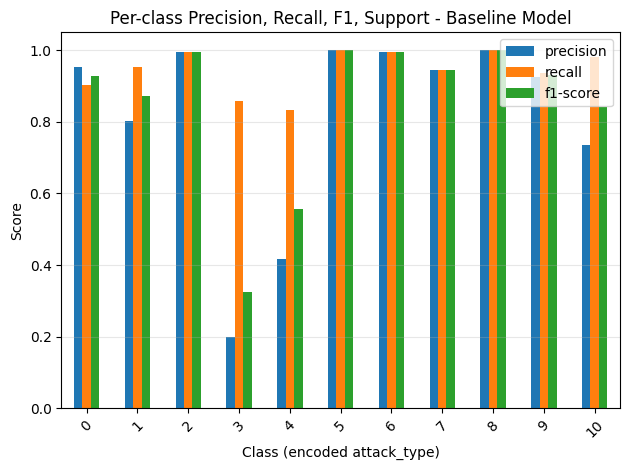

In [19]:
# function for visualizing Precision, Recall, F1 per class for all models
def visualize_class_metrics(report_df, model_name):
    class_metrics = report_df.iloc[:-3][['precision', 'recall', 'f1-score']]

    plt.figure(figsize=(10,6))
    class_metrics.plot(kind='bar')
    plt.title("Per-class Precision, Recall, F1, Support - " + model_name)
    plt.xlabel("Class (encoded attack_type)")
    plt.ylabel("Score")
    plt.ylim(0, 1.05)
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Visualizing Precision, Recall, F1 per class
base_report = classification_report(y_test, y_prediction, output_dict=True)
base_report_df = pd.DataFrame(base_report).transpose()
visualize_class_metrics(base_report_df, 'Baseline Model')

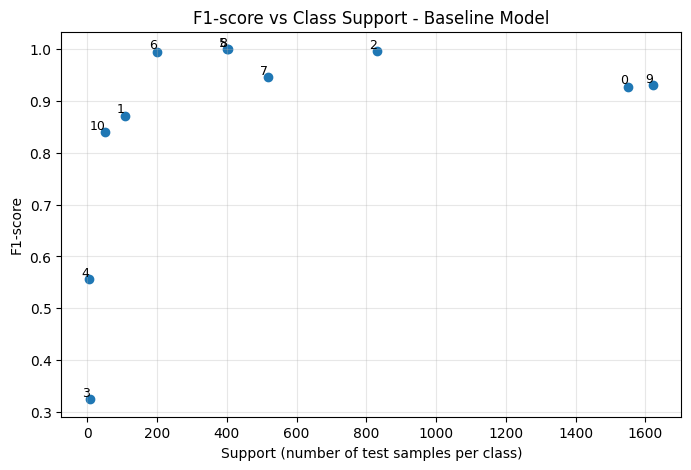

In [20]:
# function for visualizing F1-score vs Support per class for all models
def visualize_f1_vs_support(report_df, model_name):
    class_rows = report_df.iloc[:-3]
    f1_scores = class_rows['f1-score']
    supports = class_rows['support']

    plt.figure(figsize=(8,5))
    plt.scatter(supports, f1_scores)
    for cls, x, y in zip(class_rows.index, supports, f1_scores):
        plt.text(x, y, str(cls), fontsize=9, ha='right', va='bottom')

    plt.xlabel("Support (number of test samples per class)")
    plt.ylabel("F1-score")
    plt.title("F1-score vs Class Support - " + model_name)
    plt.grid(alpha=0.3)
    plt.show()

#visualizing F1-score vs Support per class for baseline model
visualize_f1_vs_support(base_report_df, "Baseline Model")

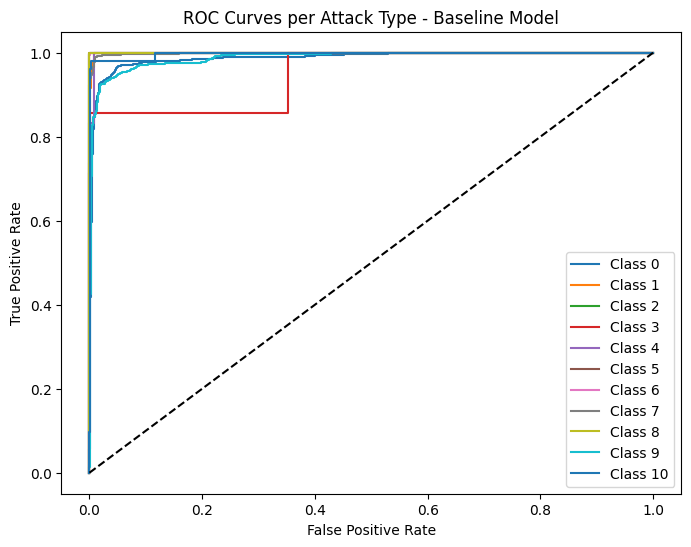

In [21]:
def plot_roc_curves(test_data, probability_data, model_name):
    y_test_bin = label_binarize(test_data, classes=np.unique(y_test))
    n_classes = y_test_bin.shape[1]

    plt.figure(figsize=(8,6))

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probability_data[:, i])
        plt.plot(fpr, tpr, label=f"Class {i}")

    plt.plot([0,1],[0,1],'k--')
    plt.title("ROC Curves per Attack Type - " + model_name)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

# Visualizing ROC curve for each class in baseline model
plot_roc_curves(y_test, y_probability, "Baseline Model")

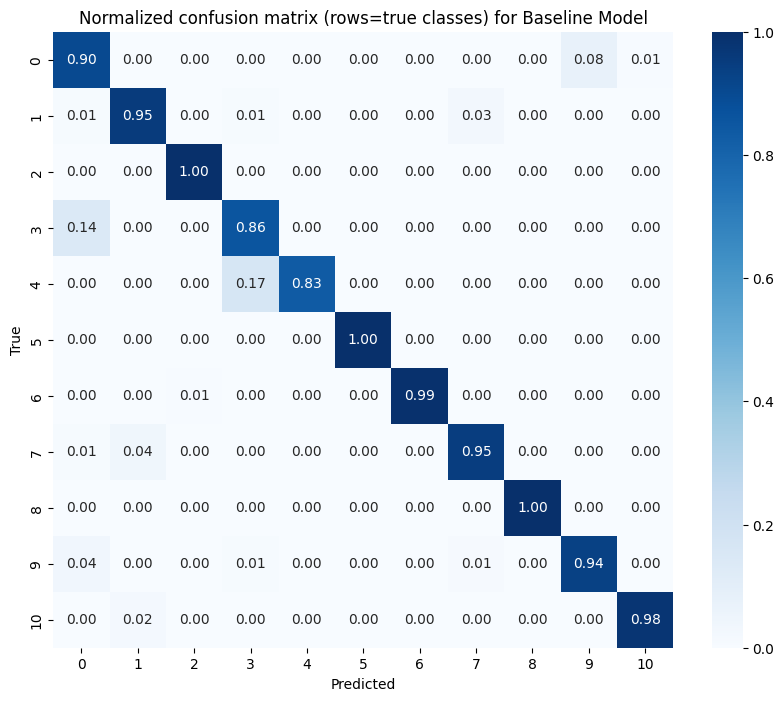

In [22]:
# Function to plot confusion matrix for all models dynamically
def plot_confusion_matrix(test_data, prediction_data, model_name):
    cm = confusion_matrix(test_data, prediction_data)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(10,8))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues')
    plt.title("Normalized confusion matrix (rows=true classes) for "+ model_name)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

#visualize confusion matrix for baseline model
plot_confusion_matrix(y_test, y_prediction, "Baseline Model")

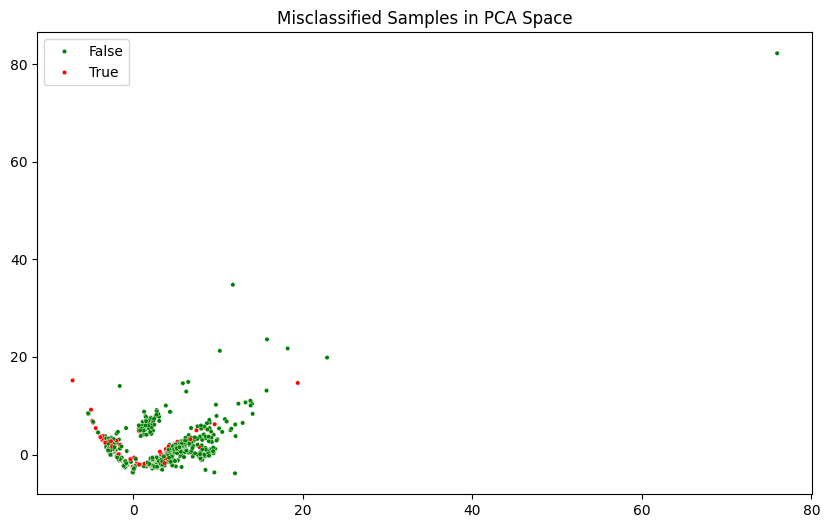

In [23]:
#showing misclassified samples in PCA after prediction with baseline model
X_test_pca = pca.transform(X_test_scaled)

plt.figure(figsize=(10,6))
sns.scatterplot(x=X_test_pca[:,0], y=X_test_pca[:,1],
                hue=(y_test != y_prediction),
                palette={True:"red", False:"green"}, s=10)
plt.title("Misclassified Samples in PCA Space")
plt.show()

### Baseline Models Results Explanation
The overall accuracy and F1 score are decent, sitting at arround 0.95 each, the ROC-AUC score is of 0.993 with a very strong separability, however upon further reading of the metrics, the data demonstrates to still be veyr unbalanced with a very good precission for classes with lots of samples, and incredible low precision and F1 for small classes (0.22 for class 3 and 0.42 for class 4). It can also be seen in the confusion matrix that some large classes migth be misclassified and confused for different classes, indicating a possible overlap in feature space. In order to fix this issues, imbalance in small classes should be addressed and when using different models and evaluation of classes and their priority (as well as some error analysis should be done.)

The visualized classification report shows that attack classes with many samples achieve nearly accurate detection, while minority classes class 3 and class 4 show high Recall and low precision and F1-score, indicating that the model struggles with minority class discrimination when the decision boundaries are overlapping.

The F1-score vs Class Support plot confirms that for the baseline model there is a strong correlation between the amount of samples per class during training, the better the F1-score, so minority classes are rarely considered during predictions

The plotted ROC Curves per category shows most classes achieve a 99.3% AUC, confirming excellent rank ordering of predictions, however minority classes display fluctuations causing instability, as they are recognized but the model misclassifies them beacuse highclass ambiguity.

The normalized confusion matrix shows the classes 3 and 4 spread across the dominant classes 0 and 9, while approximately 4% of class 1 gets misclassified as class 7, and the dominant classes can sometimes also be confused with one another. These observations could hint that if classes share feature space and their boundaries are not clear enough there won;t be accurate predictions because logistic regression relies on linear separation.

The plotting of misclassified samples shows that misclassified samples cluster in areas where attack classes overlap, confirming that errors occur mainly in feature regions with high ambiguity.

In [24]:
#Applying GridSearchCV to Logistic Regression
param_grid_lr = {
    'C': [0.1, 1, 5, 10],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [200, 500, 1000]
}

grid_lr = GridSearchCV(LogisticRegression(random_state=42),
                       param_grid_lr,
                       cv=3,
                       scoring='f1_weighted',
                       n_jobs=-1)

grid_lr.fit(X_train_scaled, y_train)

#displaying results of hyperparameters tuning with GridSearchCV for Logistic Regression
print("Best LR params:", grid_lr.best_params_)

Best LR params: {'C': 10, 'max_iter': 500, 'solver': 'lbfgs'}


# Implementation of Advance Models
The chosen advanced models that will be compared against the baseline model are Random Forest, as it is a very stron nonlinear classifier and handles imbalanced classes better than Logistic Regresion; and SVM which is good for PCA-like boundares and scaled data.

In [26]:
# Training Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
rf_proba = rf_model.predict_proba(X_test_scaled)

# Displaying Random Forest performance
print("\n--- Random Forest Performance ---")
print(classification_report(y_test, rf_pred))
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("F1-score:", f1_score(y_test, rf_pred, average='weighted'))
print("ROC-AUC:", roc_auc_score(y_test, rf_proba, multi_class='ovr'))


--- Random Forest Performance ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1550
           1       0.95      0.94      0.95       107
           2       1.00      1.00      1.00       829
           3       1.00      0.86      0.92         7
           4       1.00      0.83      0.91         6
           5       1.00      1.00      1.00       400
           6       1.00      1.00      1.00       200
           7       0.98      0.99      0.99       518
           8       1.00      1.00      1.00       402
           9       0.99      0.99      0.99      1622
          10       0.98      0.98      0.98        51

    accuracy                           0.99      5692
   macro avg       0.99      0.96      0.98      5692
weighted avg       0.99      0.99      0.99      5692

Accuracy: 0.9926212227687983
F1-score: 0.992607197911007
ROC-AUC: 0.9921593928217991


<Figure size 1000x600 with 0 Axes>

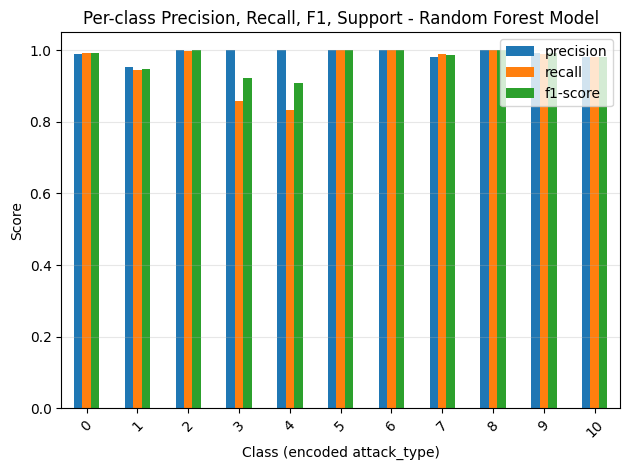

In [27]:
#Visualizing Precision, Recall, F1 per class for Random Forest model
rf_report = classification_report(y_test, rf_pred, output_dict=True)
rf_report_df = pd.DataFrame(rf_report).transpose()
visualize_class_metrics(rf_report_df, 'Random Forest Model')

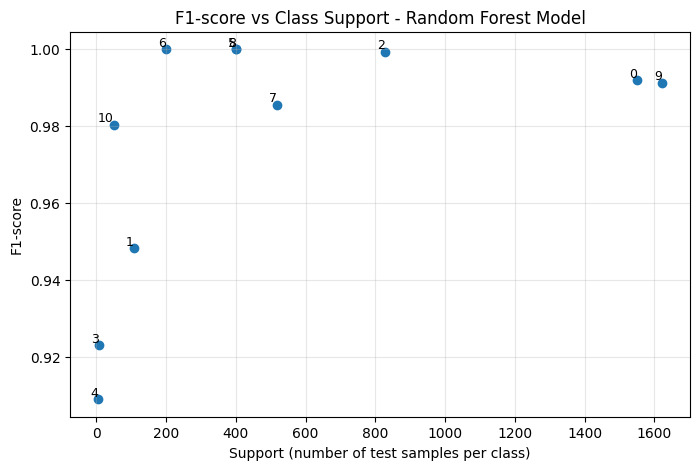

In [28]:
#visualizing F1-score vs Support per class for Random Forest model
visualize_f1_vs_support(rf_report_df, "Random Forest Model")

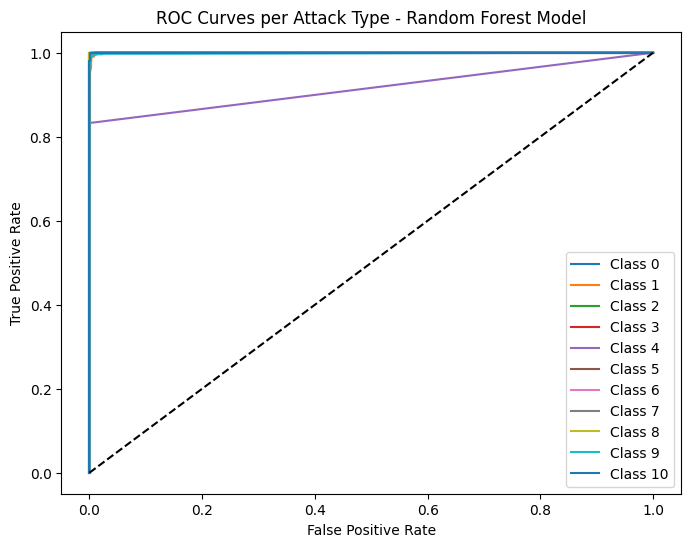

In [29]:
# Visualizing ROC curve for each class in Random Forest model
plot_roc_curves(y_test, rf_proba, "Random Forest Model")

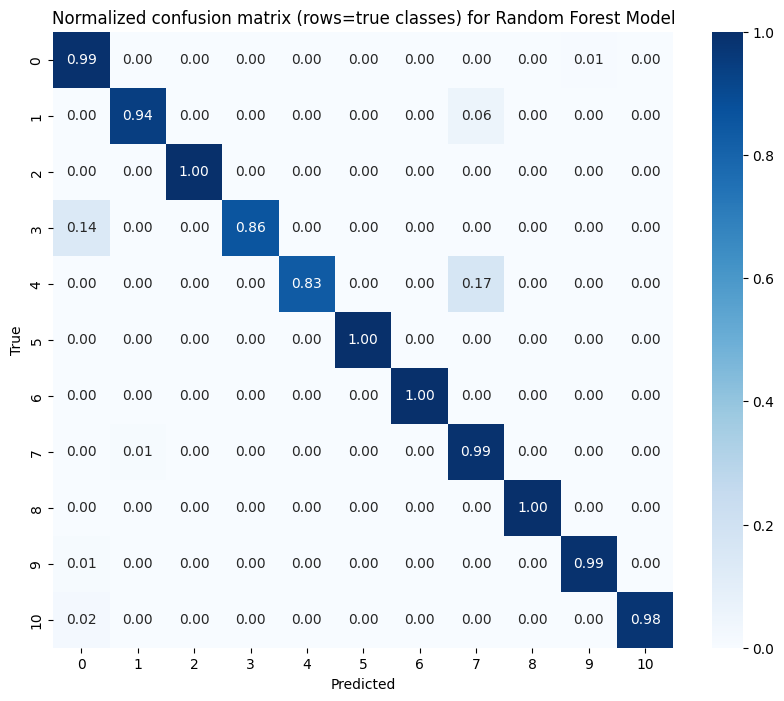

In [30]:
# Visualizing Random Forest Confusion Matrix
plot_confusion_matrix(y_test, rf_pred, "Random Forest Model")

### Random Forest Results Explanation
Random Forest achieved high performance, reaching an accuracy, F1-score of 99%, and a ROC-AUC of 0.992, making it a very reliable at recognizing the different attacks on the dataset.

The classification report shows that majority classes obtain
an F1-score of at least 98 % which means the classifier performs consistently on the most common attacks, while minority classes, in specific classes 3 and 4 which have low support reach an F1-scores of 92 % and 91 % respectively.

The F1 vs class support plot further proves that Random Forest remains supe-
rior in predicting minimal classes.

The plotted ROC curves per class display nearly perfect separation which confirms low FPR and high TPR. Even weakest class remains above ROC-AUC 0.83.

In the plotted Confusion Matrix shows the diagonal contains nearly pure dark blue, confirming the model's predictions match ground truth with over 98 % per class, with minor confusion between attack scans either because they are minority classes, this could be interpreted as real network ambiguity rather than weakness of the model.

In [31]:
# Training SVM model
svm_model = SVC(
    C=10,
    kernel='rbf',
    gamma='scale',
    probability=True,
    class_weight='balanced',
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
svm_proba = svm_model.predict_proba(X_test_scaled)

# Displaying SVM performance
print("\n--- SVM Performance ---")
print(classification_report(y_test, svm_pred))
print("Accuracy:", accuracy_score(y_test, svm_pred))
print("F1-score:", f1_score(y_test, svm_pred, average='weighted'))
print("ROC-AUC:", roc_auc_score(y_test, svm_proba, multi_class='ovr'))


--- SVM Performance ---
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1550
           1       0.82      0.96      0.89       107
           2       1.00      1.00      1.00       829
           3       0.30      0.86      0.44         7
           4       0.40      1.00      0.57         6
           5       1.00      1.00      1.00       400
           6       1.00      1.00      1.00       200
           7       0.97      0.96      0.97       518
           8       1.00      1.00      1.00       402
           9       0.99      0.96      0.97      1622
          10       0.94      0.94      0.94        51

    accuracy                           0.98      5692
   macro avg       0.85      0.97      0.89      5692
weighted avg       0.98      0.98      0.98      5692

Accuracy: 0.9764581869290232
F1-score: 0.9775154960848769
ROC-AUC: 0.9984022345972711


<Figure size 1000x600 with 0 Axes>

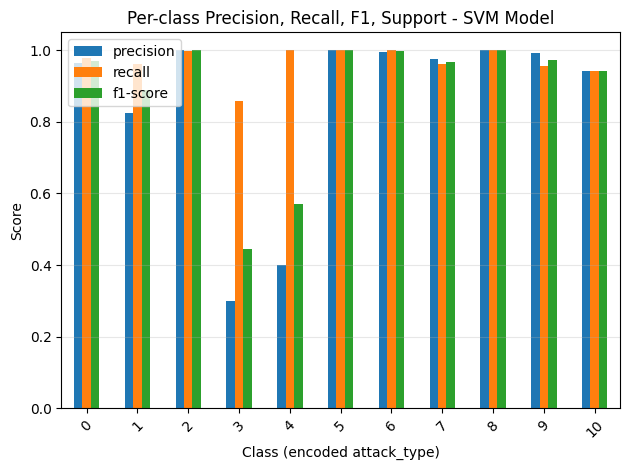

In [32]:
#Visualizing Precision, Recall, F1 per class for SVM model
svm_report = classification_report(y_test, svm_pred, output_dict=True)
svm_report_df = pd.DataFrame(svm_report).transpose()
visualize_class_metrics(svm_report_df, "SVM Model")

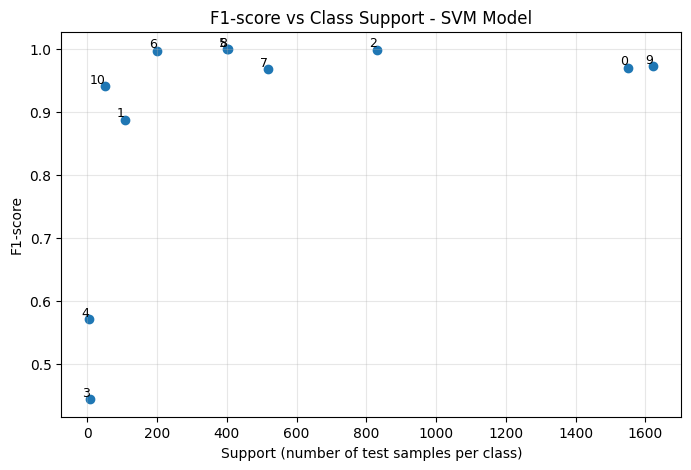

In [33]:
#visualizing F1-score vs Support per class for SVM model
visualize_f1_vs_support(svm_report_df, "SVM Model")

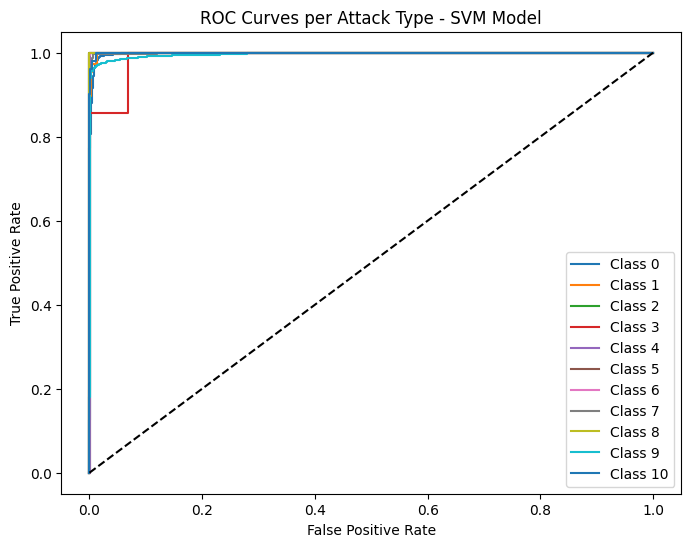

In [34]:
# Visualizing ROC curve for each class in SVM model
plot_roc_curves(y_test, svm_proba, "SVM Model")

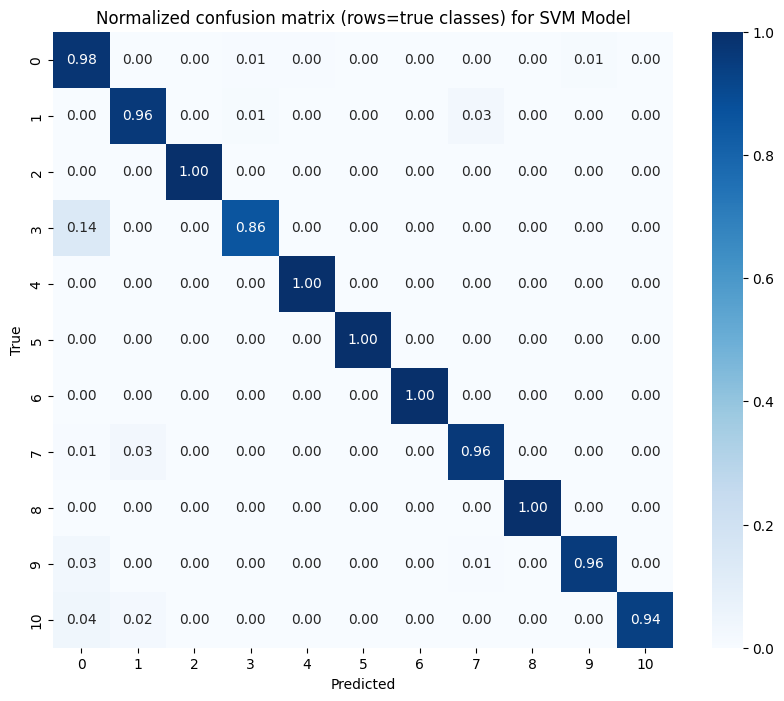

In [37]:
# Visualizing SVM Confusion Matrix
plot_confusion_matrix(y_test, svm_pred, "SVM Model")

### SVM Results Explanation
The model reached an accuracy score of 97.6%, a F1-score of 98% and a ROC-AUC score of 0.998. This indicates excellent overall classification capability across the multiclass categorization problem, successfully distinguishing most attack types in the test set and effectively identifying and handling overlapping feature distributions.

The Classification Report shows that frequent attack types show almost perfect precision and recall, with F1-scores between 0.97 and 1.00 but categories with lower support display much lower performance, often being confused or incorrectly labeled like classes 3 and 4 which have the least number of samples having f1-score of 0.44 and 0.57 respectively.

The plotted F1 vs class support diagram shows once more the clear correlation between the number of samples and the F1-score value. The differences between classes with over 500 samples and classes with less than 50, confirms that data scarcity, not necessarily the model itself is the primary cause of misclassification.

The ROC curves plot shows that most classes scored an AUC between 0.99 and 1.00, with AUC slightly lower for minority classes but still high at around 85% for class 3, signaling that good separability despite noise and that classification is still significantly better than random guessing.

The confusion matrix demonstrates correct classification. However, the minority class 3 still contributes to the prediction mistakes. there seem to be tiny spillovers in classes 0 and 9 that could mean some attacks are being classified as non malicious.

In [36]:
#Tuning hyperparameters of Random Forest model with GridSearch (small grids)
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 15],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_scaled, y_train)
best_rf = grid_rf.best_estimator_

# Displaying best Random Forest parameters results
print("Best RF params:", grid_rf.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best RF params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [38]:
# Tuning hyperparameters of SVM model with GridSearchCV
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    SVC(probability=True, random_state=42, class_weight='balanced'),
    param_grid_svm,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train_scaled, y_train)
best_svm = grid_svm.best_estimator_

# Displaying best SVM parameters results
print("Best SVM params:", grid_svm.best_params_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best SVM params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}


### Hyperparameter tuning results with GridSearchCV

Before aggregating all selected models into the Ensemble model, hyperparameter tuning was applied to ensure the models have the best setting to ensure prediction accuracy and benefit the results of the ensemble model. The resuts for each trained model are:

Best Logistic Regression parameterss:
{'C': 10, 'max_iter': 500, 'solver': 'lbfgs'}

Best Random Forest parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

Best SVM parameters:
{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}


In [39]:
# Predicting with a voting classifier emsemble of the base model + the two advance models
voting_model = VotingClassifier(
    estimators=[
        ("lr", grid_lr.best_estimator_),
        ("rf", best_rf),
        ("svm", best_svm)
    ],
    voting="soft"
)

voting_model.fit(X_train_scaled, y_train)
voting_pred = voting_model.predict(X_test_scaled)
voting_proba = voting_model.predict_proba(X_test_scaled)

# Displaying Voting Ensemble performance
print("\n--- Voting Ensemble Performance ---")
print(classification_report(y_test, voting_pred))
print("Accuracy:", accuracy_score(y_test, voting_pred))
print("F1-score:", f1_score(y_test, voting_pred, average='weighted'))
print("ROC-AUC:", roc_auc_score(y_test, voting_proba, multi_class='ovr'))


--- Voting Ensemble Performance ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1550
           1       0.93      0.93      0.93       107
           2       1.00      1.00      1.00       829
           3       1.00      0.86      0.92         7
           4       1.00      0.83      0.91         6
           5       1.00      1.00      1.00       400
           6       1.00      1.00      1.00       200
           7       0.98      0.98      0.98       518
           8       1.00      1.00      1.00       402
           9       0.99      0.97      0.98      1622
          10       1.00      0.98      0.99        51

    accuracy                           0.99      5692
   macro avg       0.99      0.96      0.97      5692
weighted avg       0.99      0.99      0.99      5692

Accuracy: 0.9859451862262825
F1-score: 0.9859420250827453
ROC-AUC: 0.9997636632225855


<Figure size 1000x600 with 0 Axes>

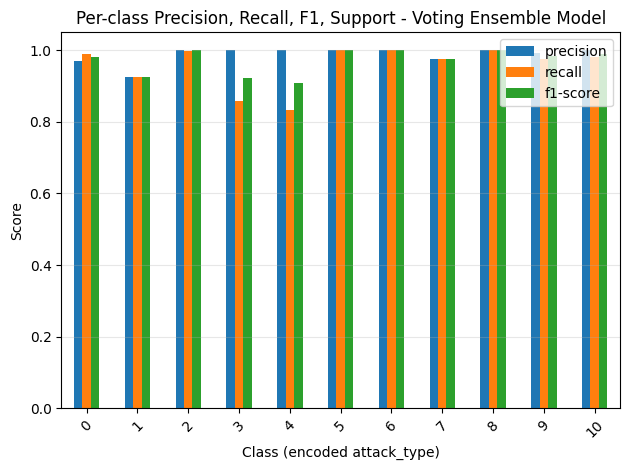

In [40]:
#Visualizing Precision, Recall, F1 per class for Voting Ensemble model
voting_report = classification_report(y_test, voting_pred, output_dict=True)
voting_report_df = pd.DataFrame(voting_report).transpose()
visualize_class_metrics(voting_report_df, "Voting Ensemble Model")

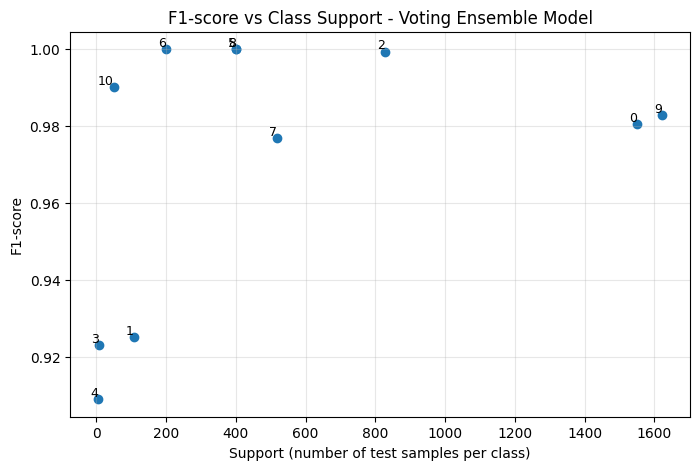

In [41]:
#visualizing F1-score vs Support per class for Voting Ensemble model
visualize_f1_vs_support(voting_report_df, "Voting Ensemble Model")

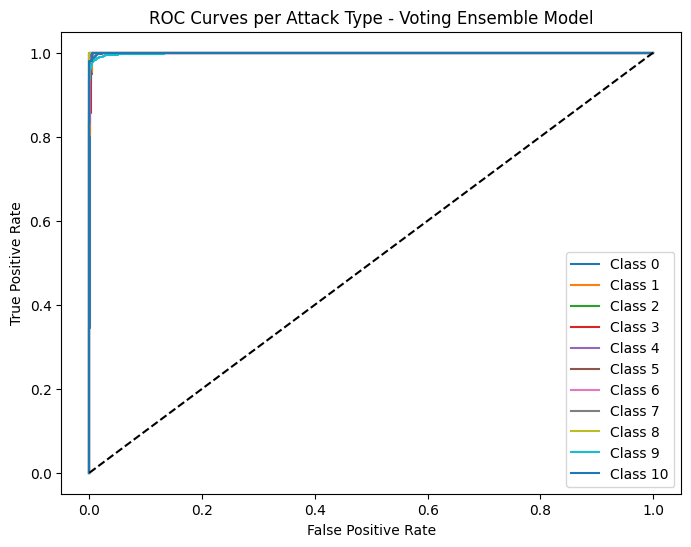

In [42]:
# Visualizing ROC curve for each class in Voting Ensemble model
plot_roc_curves(y_test, voting_proba, "Voting Ensemble Model")

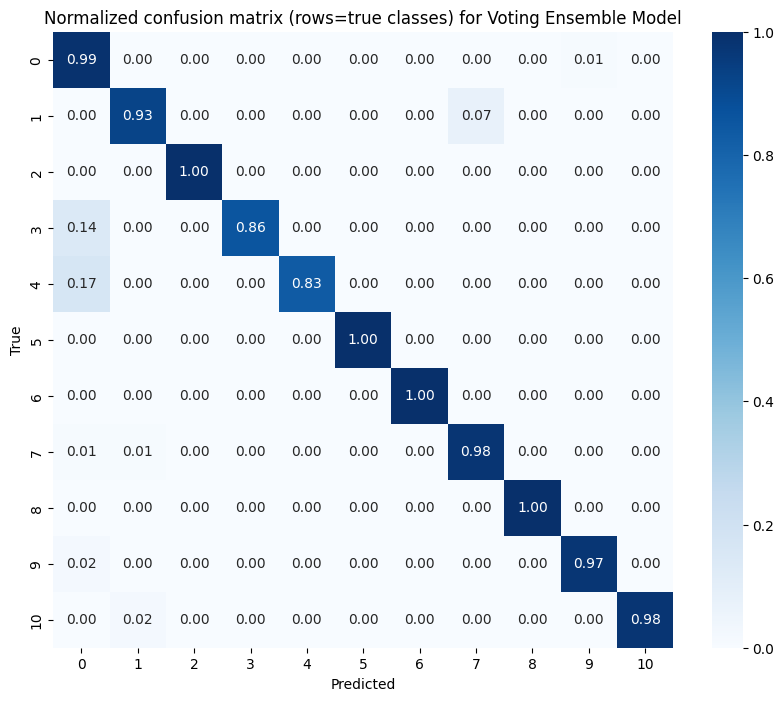

In [43]:
# Visualizing Voting Ensemble Confusion Matrix
plot_confusion_matrix(y_test, voting_pred, "Voting Ensemble Model")

### Ensemble Model Results Explanation

This model demonstrated strong performance across all the evaluation criteria with 98.5 % for accuracy and F1-score and a ROC-AUC score of 0.999 which shows the effectiveness of aggregating all the selected models.

The classification report shows the ensemble provides excellent consis-
tency across precision, recall, and F1-score for almost all attack types. Majority classes have scores above 0.98, but minority classes such as class 3 and class 4 maintain decent F1-scores around 0.91 and 0.93. This suggests that the model has largely overcome class imbalance, but classes with low support remain difficult to categorize.

The F1 vs support plot again visualizes the strongly positive relationship  between high-support classes and almost perfect results, while the lowest-support classes score lower. it’s worth noticing that class 10 has a total of 51 samples and a F1-score of 0.99, meaning the minority classes in the ensemble perform way better than Logistic Regression and SVM, showing improvement on minority class robustness.

The ROC curves for all eleven classes are tightly concentrated in the top-left corner, showing highly confident separability.

The confusion matrix confirms that most samples are classified correctly, with the diagonal cells approaching 1.0 for all major classes and, once again, misclassification mainly occurring in the minority classes 3 (0.14) and 4 (with 0.17)


## Visualized Model Comparisons

In [44]:
model_results = {}

# function to compute and store model results
def store_results(name, model, X, y_true):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)

    model_results[name] = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1_score": f1_score(y_true, y_pred, average='weighted'),
        "ROC-AUC": roc_auc_score(y_true, y_proba, multi_class='ovr')
    }

# Store performances
store_results("Logistic Regression", grid_lr.best_estimator_, X_test_scaled, y_test)
store_results("Random Forest", best_rf, X_test_scaled, y_test)
store_results("SVM", best_svm, X_test_scaled, y_test)
store_results("Voting Ensemble", voting_model, X_test_scaled, y_test)

model_results

# results converted to table form
results_df = pd.DataFrame(model_results).T

#displaying results table
results_df

,Accuracy,F1_score,ROC-AUC
Logistic Regression,0.957309,0.957194,0.997082
Random Forest,0.992621,0.992607,0.992159
SVM,0.976458,0.977515,0.998388
Voting Ensemble,0.985945,0.985942,0.999764


The table above shows the scores for the most relevant metrics for model performance evaluation, in a machine learning project it is imperative to compare the effectiveness of the evaluated models to understand whether the decisions taken benifitted the solution of the problem at hand.

The table makes it clear that the Voting Ensemble, Random Forest, and SVM models achieved an almost perfect category classification, all exceeding 98% accuracy and F1-scores, while Logistic Regression was left noticeably behind at approximately 96%.Random Forest obtained the highest overall accuracy (99.26 %), closely followed by the Ensemble model(98.59 %) and SVM (97.64 %).

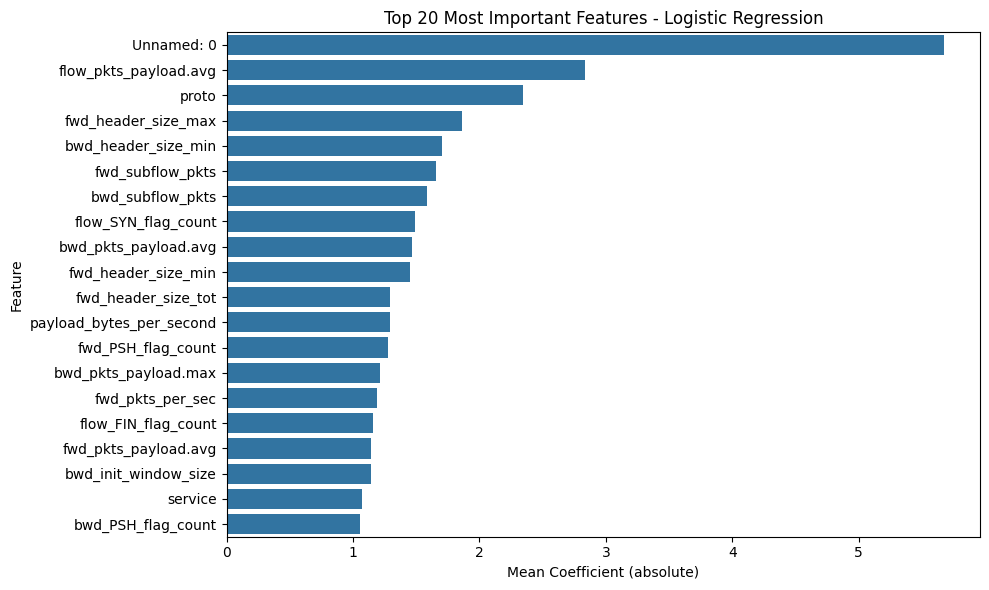

In [46]:
coefs = np.abs(baseline_model.coef_)
mean_importance = np.mean(coefs, axis=0)

#Visualizing Feature Importances for the top 20 features for baseline model
fi_lr_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': mean_importance
}).sort_values(by="Importance", ascending=False).head(20)

# Visualization
plt.figure(figsize=(10,6))
sns.barplot(data=fi_lr_df, x="Importance", y="Feature")
plt.title("Top 20 Most Important Features - Logistic Regression")
plt.xlabel("Mean Coefficient (absolute)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

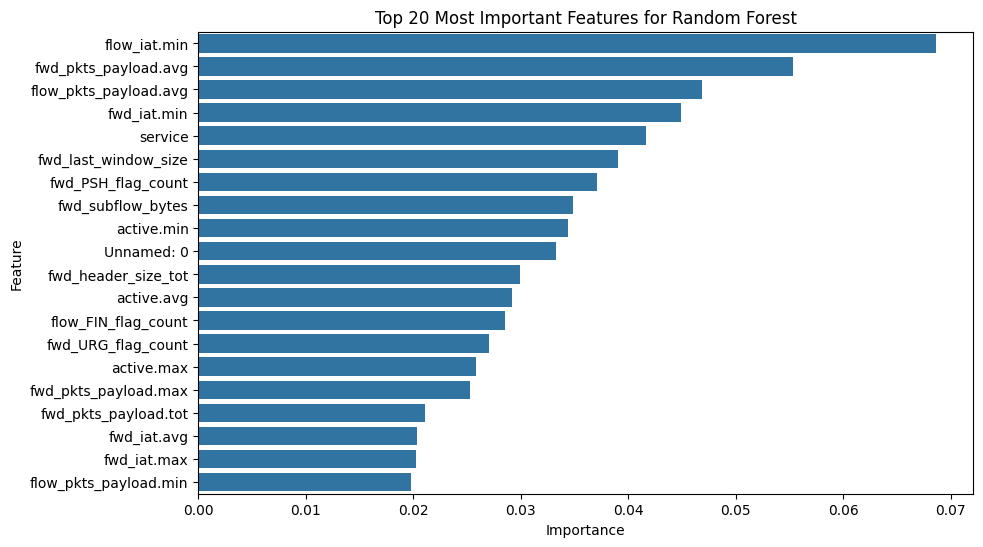

In [47]:
# Retrieving feature importance for Random Forest model
importances = best_rf.feature_importances_
features = X.columns

# converting the importances into a DataFrame for better visualization
fi_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by="Importance", ascending=False).head(20)

# Visualizing top 20 feature importances
plt.figure(figsize=(10,6))
sns.barplot(data=fi_df, x="Importance", y="Feature")
plt.title("Top 20 Most Important Features for Random Forest")
plt.show()

### Feature Importance Comparison

As both Logistic Regression and Random Forest offer the possibility of retrieve the feature importance in their classification decissions it was worth visualizing and comparing their results to see what insights could be drawn from linear and non-linear importance results.

Logistic Regression measures feature contribution based on the absolute coefficient values. Based on the plot it can be inferred that this model relies on transport layer structural features like fwd_header_size_max,
bwd_header_size_min and fwd_header_size_tot which contain data on packet structure and negotiation, fwd_subflow_pkts and bwd_subflow_pkts which are flow segmentation behavior data; and SYN/FIN/PSH flag counts that helps indicate connection initiation and tear down.

Random Forest uses Gini-based feature importance which shows that flow_iat.min (inter-arrival time minimum) is by far the most influential feature, signaling
that rapid packet bursts are giveaways for certain attacks. Other important features are fwd_pkts_payload.avg and flow_pkts_payload.avg which relate to
payload volume and consistency, fwd_iat.min and fwd_iat.max which are temporal characteristics of forward traffic, service level indicators; and some flag based attributes such as fwd_PSH_flag_count and flow_FIN_flag_count.

It can be concluded that both models agree that flow timing and control flags are highly relevant in detecting attacks. Random Forest relies more on behavioral burst patterns, while Logistic Regression places more
emphasis on packet structure characteristics.

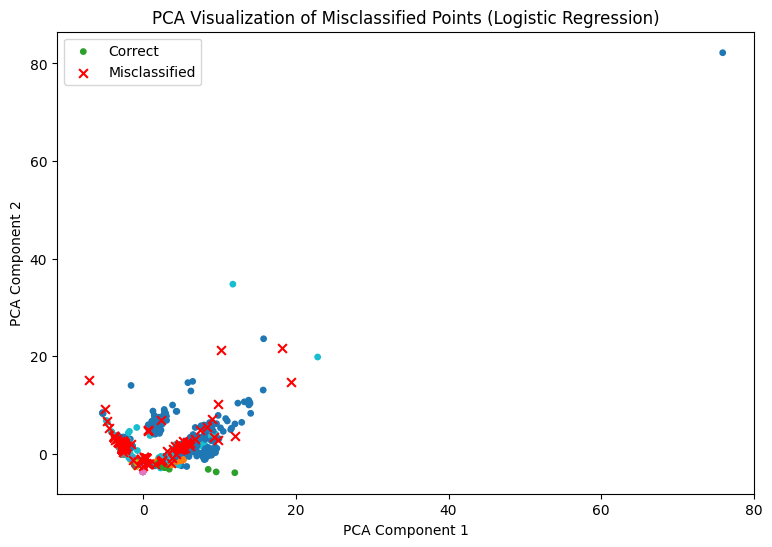

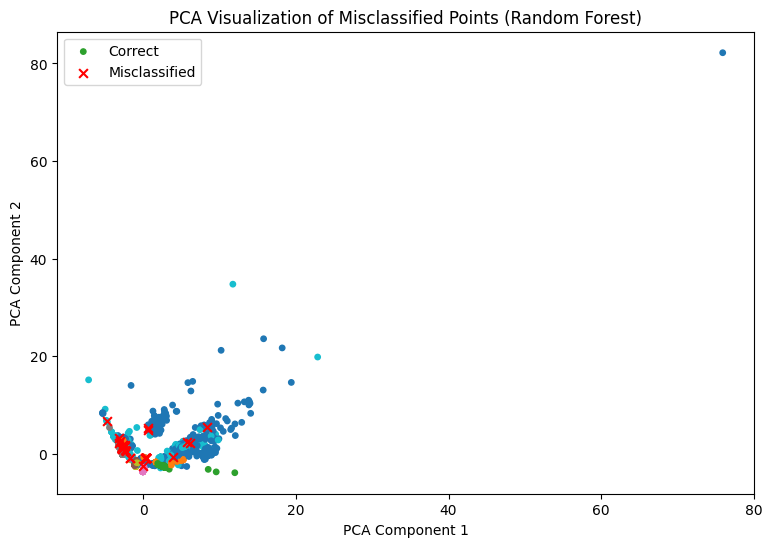

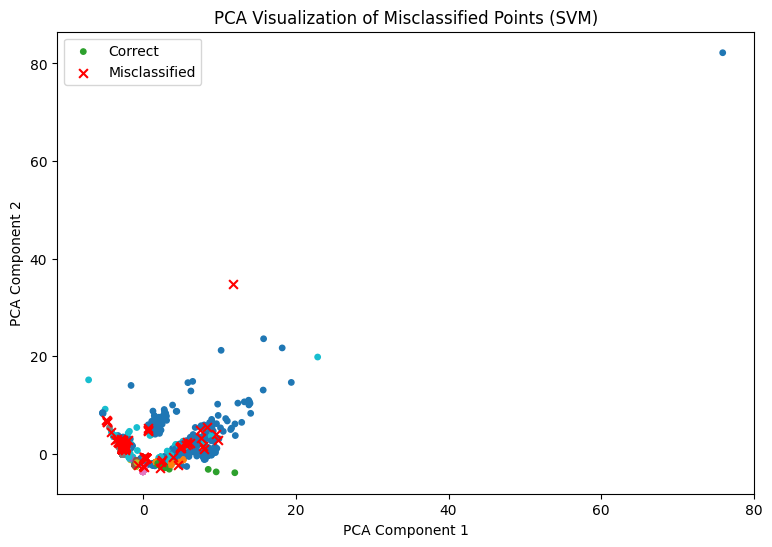

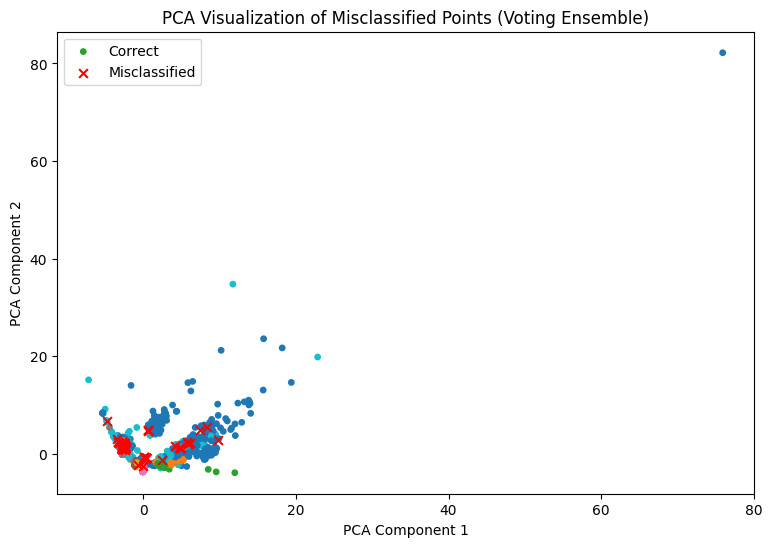

In [48]:
#PCA Misclassification visualization of all models
# Fit PCA on scaled training data
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# function to plot model's misclassifications dynamically
def plot_misclassifications(model, name):
    y_pred = model.predict(X_test_scaled)

    misclassified = y_pred != y_test

    plt.figure(figsize=(9,6))
    plt.scatter(X_test_pca[~misclassified, 0],
                X_test_pca[~misclassified, 1],
                c=y_test[~misclassified], cmap='tab10', s=15, label="Correct")

    plt.scatter(X_test_pca[misclassified, 0],
                X_test_pca[misclassified, 1],
                c='red', marker='x', s=40, label="Misclassified")

    plt.title(f"PCA Visualization of Misclassified Points ({name})")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.legend()
    plt.show()

# plot misclassification for all selected models
plot_misclassifications(grid_lr.best_estimator_, "Logistic Regression")
plot_misclassifications(best_rf, "Random Forest")
plot_misclassifications(best_svm, "SVM")
plot_misclassifications(voting_model, "Voting Ensemble")


## Misclassification plot Analysis of Selected Models

Logistic Regression misclassifications were primarily located within
dense regions of overlapping categories confirming that linear decision boundaries were not sufficient to completely separate complex traffic behaviors. It can be inferred that attacks with similar features were frequently confused with one another due to the presence of multiple red markers within the core cluster.

Random Forest showed significantly fewer misclassifications as most red points in the plot appear only at the sidelines of class clusters, visualizing how it managed to capture complex feature interactions and decision rules more effectively. The other errors seen in the plot occur only where class distributions overlap, which might be caused by the nature of network metadata.

The SVM model produced a small number of misclassifications clustered within the main overlapping region. This confirms that class confusion is caused
largely from similarity in network features. Despite some outlier errors this, the model handled non-linear boundaries substantially better than Logistic Regression.

The Voting Ensemble achieved the lowest number of misclassifications, with errors appearing only in a very reduced area of class overlap. supportting the decision of combining all the selected models to help resolve disagreements in ambiguous regions.

Across the selected models, misclassifications seem to consistently originate from the same dense PCA region where multiple categories cluster together. This suggests that these samples share very similar network flow characteristics, making them challenging to categorize even for advanced models. Fortunately, the approaches of the Ensemble model and the Random Forest model effectively mitigate these issues.

## Conclusion

The multiclass classification experiments carried out, showed that while linear methods such as Logistic Regression established a strong
baseline, they can struggle to fully capture complex and non-linear structures typically seen in malicious IoT network traffic.

The pre-processing steps applyed to the dataset, and hyperparameter tuning of models progresively improved the performance of the selected models.

Logistic Regression was a good starting point for the project but was proven to not be as efficient to solve the problem at hand as the more advanced models, because of its generalized linear structure.

Random Forest and SVM showed superior robustness in differentiating subtle differences among attacks, with the Random Forest model achieving the highest overall accuracy and reliability across all classes.

The soft-voting ensemble which combineed all three models achieved
the most balanced results, correctly identifying low support attacks while maintaining excellent generalization on the test set, making it the best candidate for deployment in IoT intrusion detection scenarios, followed by Random Forest which has almost perfect metrics and offers a higher level of interpretability through feature importance.

Although performance was high, several open challenges remained, like minority attack types exhibiting overlapping behavior that still causes occasional misclassification and  the fact minority classes such as Class 3 and Class 4 still form overlapping clusters in PCA space and are often misclassified even in the more advance models, although to a lesser extent.

Finally, this project did manage to successfully meet its objective to build a supervised Machine Learning Model capable of classifying malicious IoT traffic with high precision and practical deployment potential, that could in turn be deployed into a real world intrusion detection system, with a few extra adjustments like the possibility to adapt to new and unseen threats and a more dynamic retraining to counter act changing patterns in cyber attacks methodologies.